# Chapter 7: Polyhedra

**Source Span.** `Discrete and Computational Geometry, 2nd Edition.pdf`, Chapter 7, printed pages 199-252 (PDF pages 214-267).

**Chapter goal.** Build a computational notebook for polyhedral geometry: regular solids are constrained by angle sums, Euler characteristic controls surface topology, curvature is concentrated at vertices, rigidity and flexibility require different certificates, unfoldings become spanning-tree choices, shortest paths are straight after cutting, and Alexandrov gluing is an angle-and-curvature existence theorem.

The notebook uses original diagrams, tables, and finite checks. It follows the source chapter's structure without copying textbook prose, exercises, figures, screenshots, or page crops.


## Computational Translation Guide

| Chapter idea | Computational representation | Inspection target |
| --- | --- | --- |
| Platonic solids | table of `(p,q,V,E,F)` and angle sums | only five regular convex possibilities satisfy angle deficit |
| Euler formula | surface ledger with genus | `V-E+F=2` for convex polyhedra and `2-2g` for closed orientable surfaces |
| polyhedral Gauss-Bonnet | angle defects at vertices | total curvature equals `4*pi` for sphere-like convex polyhedra |
| Cauchy rigidity | sign-change graph on a cycle | local face congruence is not the same as flexible volume-preserving motion |
| Durer unfolding | cube net and dual spanning tree | a cut tree has `F-1` edges and connects all faces |
| shortest paths/cut locus | unfold faces so geodesic becomes straight | cutting changes the surface into a planar development |
| Alexandrov gluing | angle ledger around glued vertices | positive curvature sums to `4*pi` and each glued angle total is at most `2*pi` |


## Visual Storyboard

1. **Platonic angle board.** List the five regular convex polyhedra and plot the angle deficit that makes the list finite.
2. **Euler and Gauss-Bonnet board.** Compare `(V,E,F)` and vertex curvature for tetrahedron, cube, and icosahedron.
3. **Rigidity/flexibility schematic.** Show a sign-change cycle for Cauchy's rigidity proof idea and a Bellows-theorem volume contrast ledger.
4. **Unfolding board.** Draw a cube net with its dual spanning tree certificate.
5. **Shortest path and Alexandrov board.** Use a planar development and gluing angle ledger to turn 3D surface claims into checkable diagrams.


In [1]:
from pathlib import Path
import sys, json, math, itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon as MplPolygon
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import networkx as nx
from IPython.display import display, Markdown

BOOK_ROOT = next(candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate/'AGENTS.md').exists() and (candidate/'source_map.json').exists())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import chapter_artifact_root, save_json, save_csv, save_matplotlib, assert_artifacts, display_artifact

UNIT_KEY='chapter-07-polyhedra'
ARTIFACT_ROOT=chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES, TABLES, CHECKS = ARTIFACT_ROOT/'figures', ARTIFACT_ROOT/'tables', ARTIFACT_ROOT/'checks'
artifact_paths=[]
plt.rcParams.update({'figure.figsize':(7,5), 'axes.grid':True})


## Source Coverage And Library Routing

Polyhedra need both 3D and graph views. Matplotlib 3D is used for small inspectable surfaces; NetworkX is used where the chapter's object is genuinely graph-theoretic, such as cut trees and rigidity sign cycles. CSV and JSON ledgers record the counts, angle sums, curvature totals, and gluing conditions so that the notebook checks the same invariants the chapter emphasizes.


In [2]:
source_coverage={
    'Platonic solids and angle-sum restriction': True,
    'Euler polyhedral formula': True,
    'genus extension of Euler characteristic': True,
    'polyhedral Gauss-Bonnet': True,
    'Cauchy rigidity and Bellows contrast': True,
    'Durer unfolding and cube nets': True,
    'dual spanning tree condition for unfoldings': True,
    'shortest paths and cut locus': True,
    'star/source unfolding orientation': True,
    'Alexandrov gluing conditions': True,
}
library_rows=[
    {'concept':'regular polyhedra', 'representation':'angle-sum and count table', 'library':'CSV + Matplotlib', 'check':'five valid convex cases'},
    {'concept':'polyhedral surfaces', 'representation':'3D facet view and curvature bars', 'library':'Matplotlib 3D', 'check':'V-E+F and total defect'},
    {'concept':'unfolding', 'representation':'cube net plus dual graph', 'library':'Matplotlib + NetworkX', 'check':'spanning tree edges F-1'},
    {'concept':'Alexandrov gluing', 'representation':'angle ledger', 'library':'CSV/JSON', 'check':'angle sums <= 2*pi and total curvature 4*pi'},
]
source_coverage_path=save_json({'source_span':'printed pages 199-252, PDF pages 214-267', 'coverage':source_coverage}, CHECKS/'source-coverage.json')
library_table=save_csv(library_rows, TABLES/'library-routing.csv')
artifact_paths.extend([source_coverage_path, library_table])


## 1. Platonic Solids From Angle Deficit

At a regular polyhedron vertex, `q` regular `p`-gons meet. A convex vertex needs the total face angle to be less than `2*pi`; otherwise the surface flattens or turns saddle-like. That single inequality leaves exactly five possibilities. The plot records the angular defect at one vertex, the seed of polyhedral curvature.


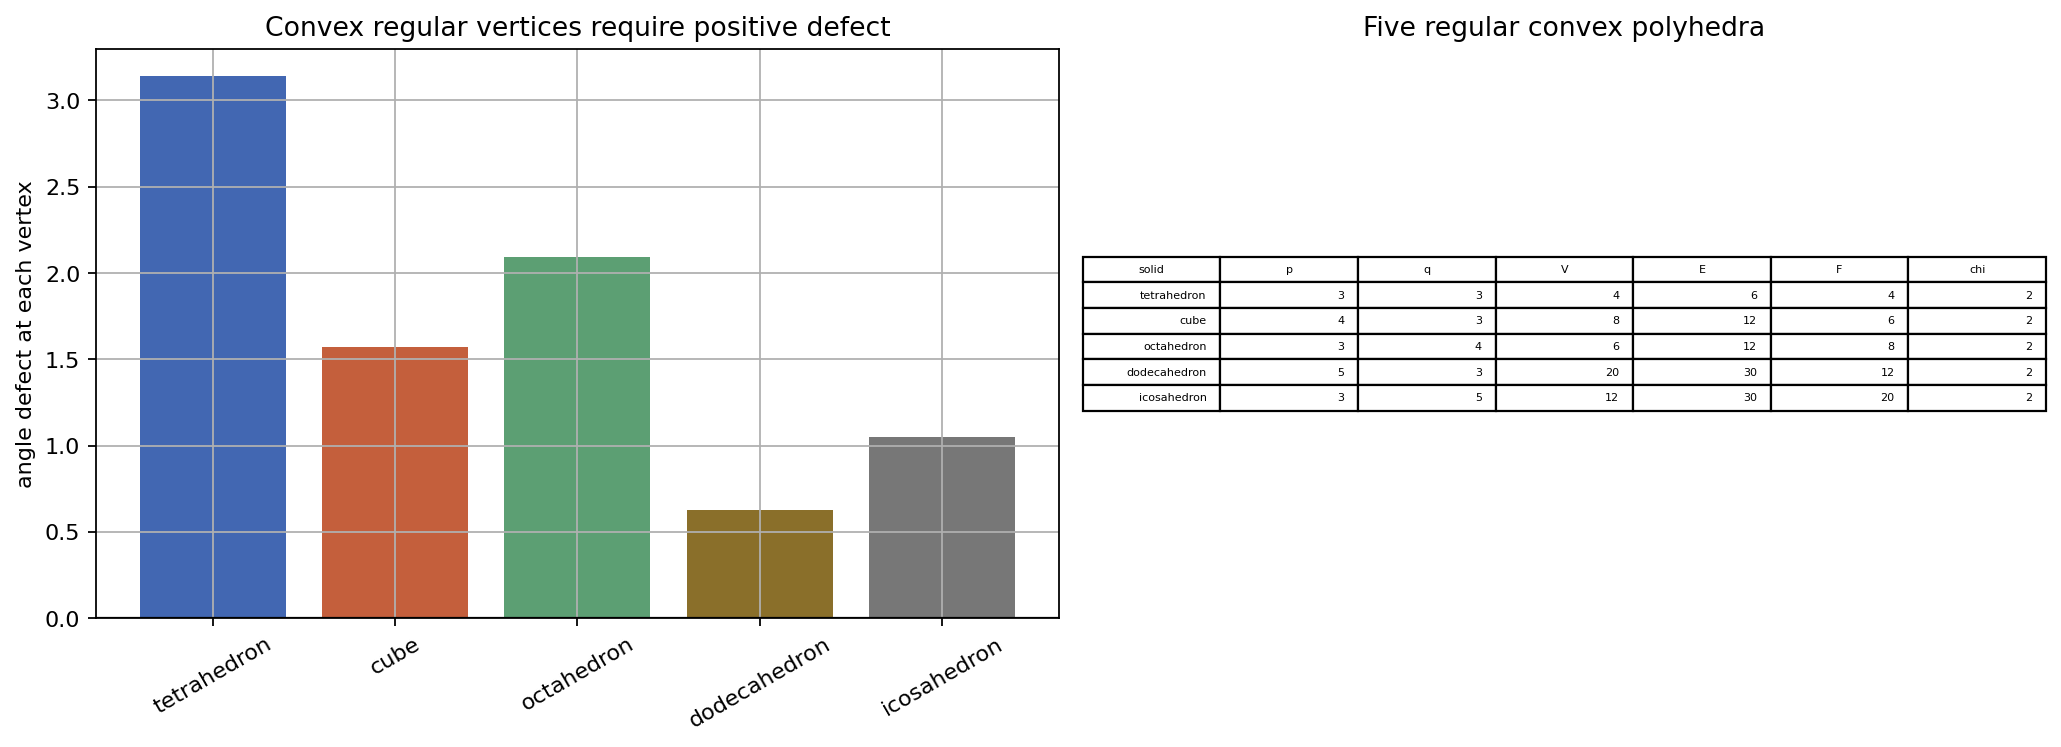

In [3]:
platonic=[
    {'solid':'tetrahedron','p':3,'q':3,'V':4,'E':6,'F':4},
    {'solid':'cube','p':4,'q':3,'V':8,'E':12,'F':6},
    {'solid':'octahedron','p':3,'q':4,'V':6,'E':12,'F':8},
    {'solid':'dodecahedron','p':5,'q':3,'V':20,'E':30,'F':12},
    {'solid':'icosahedron','p':3,'q':5,'V':12,'E':30,'F':20},
]
for row in platonic:
    face_angle=(row['p']-2)*math.pi/row['p']
    row['angle_sum_at_vertex']=row['q']*face_angle
    row['angle_defect']=2*math.pi-row['angle_sum_at_vertex']
    row['euler_characteristic']=row['V']-row['E']+row['F']

fig,axes=plt.subplots(1,2,figsize=(13,4.8))
axes[0].bar([r['solid'] for r in platonic], [r['angle_defect'] for r in platonic], color=['#4267b2','#c45f3c','#5c9f73','#8a6f2a','#777777'])
axes[0].axhline(0,color='black',linewidth=1)
axes[0].set_ylabel('angle defect at each vertex')
axes[0].set_title('Convex regular vertices require positive defect')
axes[0].tick_params(axis='x', rotation=30)
axes[1].axis('off')
cell_text=[[r['solid'], r['p'], r['q'], r['V'], r['E'], r['F'], r['euler_characteristic']] for r in platonic]
axes[1].table(cellText=cell_text, colLabels=['solid','p','q','V','E','F','chi'], loc='center')
axes[1].set_title('Five regular convex polyhedra')
fig.tight_layout()
platonic_plot=save_matplotlib(fig, FIGURES/'platonic-angle-defect-board.png')
plt.close(fig)
platonic_table=save_csv(platonic, TABLES/'platonic-solid-angle-ledger.csv')
platonic_check=save_json({'valid_regular_convex_cases':len(platonic), 'all_positive_defect':all(r['angle_defect']>0 for r in platonic), 'all_euler_two':all(r['euler_characteristic']==2 for r in platonic)}, CHECKS/'platonic-angle-checks.json')
artifact_paths.extend([platonic_plot, platonic_table, platonic_check])
display_artifact(platonic_plot, width=900)


## 2. Euler Characteristic And Polyhedral Gauss-Bonnet

For convex polyhedra, the boundary is topologically a sphere and `V-E+F=2`. Curvature is concentrated at vertices: subtract the total face angle around a vertex from `2*pi`. The total defect is `4*pi`, the polyhedral version of Gauss-Bonnet for a sphere-like surface.


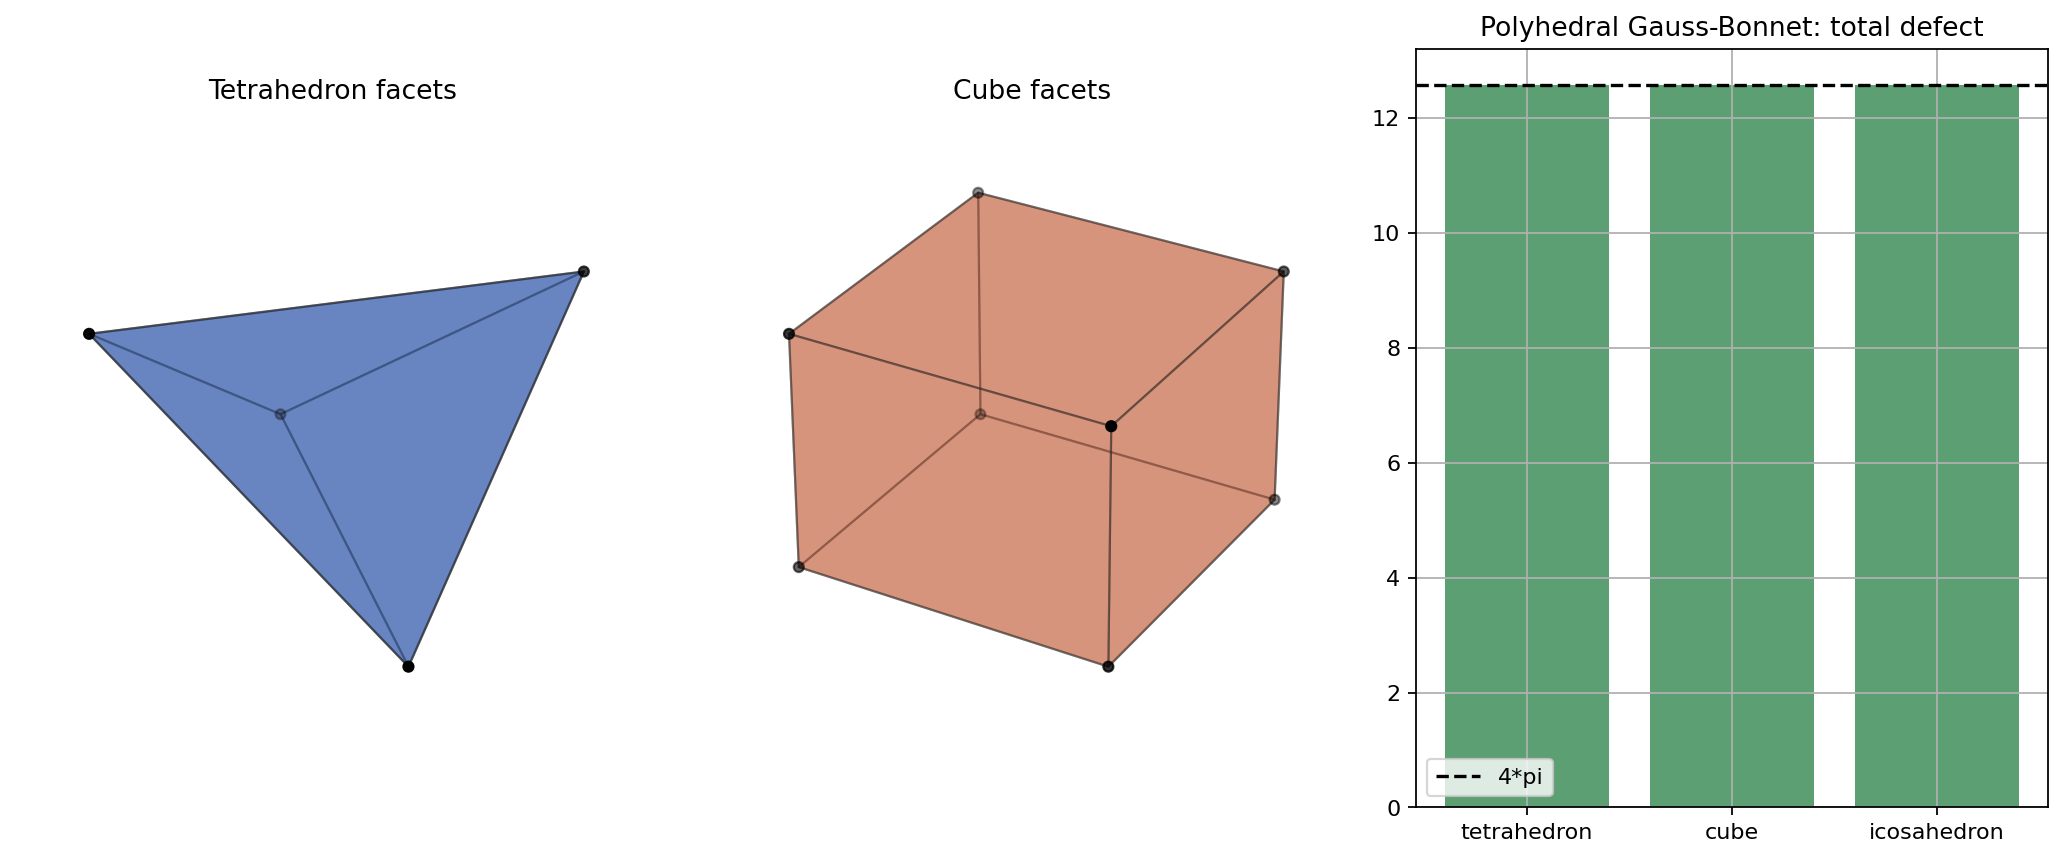

In [4]:
curvature_models=[
    {'solid':'tetrahedron','V':4,'E':6,'F':4,'faces_meeting':3,'face_angle':math.pi/3},
    {'solid':'cube','V':8,'E':12,'F':6,'faces_meeting':3,'face_angle':math.pi/2},
    {'solid':'icosahedron','V':12,'E':30,'F':20,'faces_meeting':5,'face_angle':math.pi/3},
]
for row in curvature_models:
    row['defect_per_vertex']=2*math.pi-row['faces_meeting']*row['face_angle']
    row['total_defect']=row['V']*row['defect_per_vertex']
    row['euler_characteristic']=row['V']-row['E']+row['F']

tetra_vertices=np.array([[1,1,1],[-1,-1,1],[-1,1,-1],[1,-1,-1]], dtype=float)
tetra_faces=np.array([[0,1,2],[0,3,1],[0,2,3],[1,3,2]])
cube_vertices=np.array(list(itertools.product([-1,1], repeat=3)), dtype=float)
cube_faces=[[0,1,3,2],[4,6,7,5],[0,4,5,1],[2,3,7,6],[0,2,6,4],[1,5,7,3]]
fig=plt.figure(figsize=(13,5.5))
ax1=fig.add_subplot(1,3,1,projection='3d')
ax1.add_collection3d(Poly3DCollection(tetra_vertices[tetra_faces], alpha=0.55, facecolor='#4267b2', edgecolor='#222222'))
ax1.scatter(tetra_vertices[:,0],tetra_vertices[:,1],tetra_vertices[:,2],color='black'); ax1.set_title('Tetrahedron facets'); ax1.set_axis_off()
ax2=fig.add_subplot(1,3,2,projection='3d')
ax2.add_collection3d(Poly3DCollection([cube_vertices[f] for f in cube_faces], alpha=0.42, facecolor='#c45f3c', edgecolor='#222222'))
ax2.scatter(cube_vertices[:,0],cube_vertices[:,1],cube_vertices[:,2],color='black'); ax2.set_title('Cube facets'); ax2.set_axis_off()
ax3=fig.add_subplot(1,3,3)
ax3.bar([r['solid'] for r in curvature_models], [r['total_defect'] for r in curvature_models], color='#5c9f73')
ax3.axhline(4*math.pi, color='black', linestyle='--', label='4*pi')
ax3.set_title('Polyhedral Gauss-Bonnet: total defect'); ax3.legend()
fig.tight_layout()
curvature_plot=save_matplotlib(fig, FIGURES/'polyhedral-gauss-bonnet-curvature.png')
plt.close(fig)
curvature_table=save_csv(curvature_models, TABLES/'polyhedral-curvature-ledger.csv')
curvature_check=save_json({'all_euler_two':all(r['euler_characteristic']==2 for r in curvature_models), 'all_total_defect_4pi':all(abs(r['total_defect']-4*math.pi)<1e-9 for r in curvature_models)}, CHECKS/'polyhedral-gauss-bonnet-checks.json')
artifact_paths.extend([curvature_plot, curvature_table, curvature_check])
display_artifact(curvature_plot, width=900)


## 3. Genus, Rigidity, And Flexibility Ledgers

Euler characteristic changes with topology: an orientable closed surface of genus `g` has `chi = 2 - 2g`. Rigidity is a separate geometric question. Cauchy's theorem says convex polyhedra are rigid under matching faces; Bellows-type phenomena show that flexible nonconvex polyhedra can move while preserving volume. The proof ideas are not captured by one picture, so the notebook records the sign-change cycle and the rigidity/flexibility distinction explicitly.


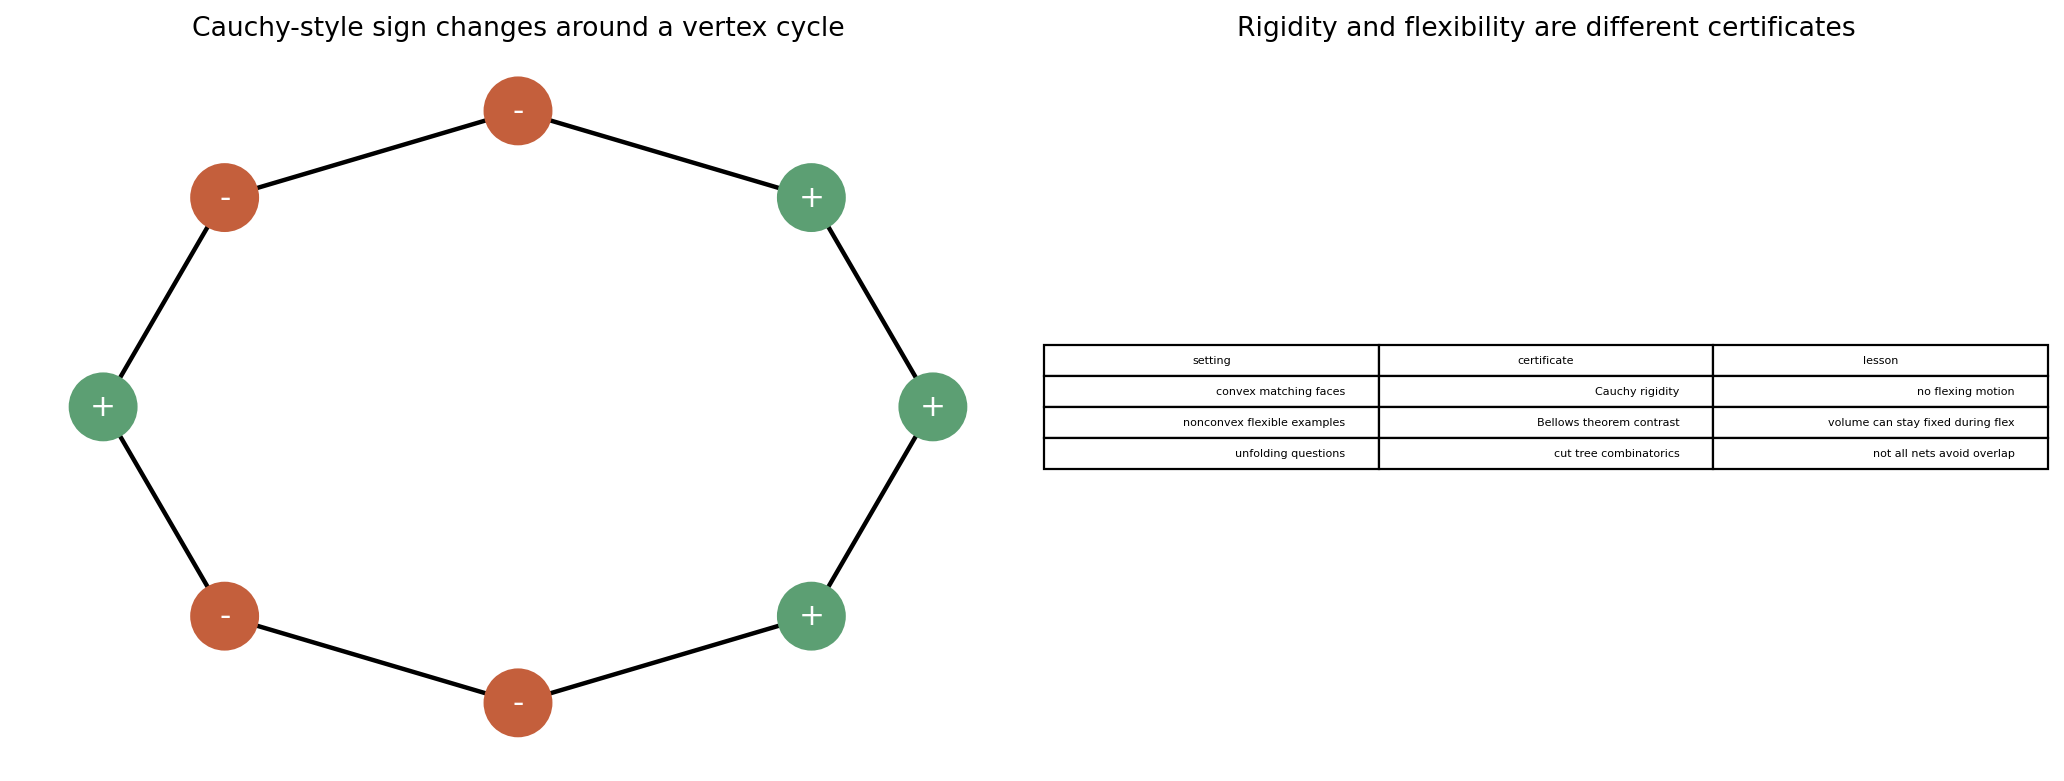

In [5]:
genus_rows=[{'surface':'sphere/convex polyhedron','genus':0,'chi':2},{'surface':'torus','genus':1,'chi':0},{'surface':'double torus','genus':2,'chi':-2}]
genus_table=save_csv(genus_rows, TABLES/'euler-genus-ledger.csv')
cycle=nx.cycle_graph(8)
signs=['+','+','-','-','+','-','-','+']
sign_changes=sum(signs[i]!=signs[(i+1)%len(signs)] for i in range(len(signs)))
pos=nx.circular_layout(cycle)
fig,axes=plt.subplots(1,2,figsize=(13,5))
nx.draw_networkx_edges(cycle,pos,ax=axes[0],width=2)
nx.draw_networkx_nodes(cycle,pos,ax=axes[0],node_color=['#5c9f73' if s=='+' else '#c45f3c' for s in signs],node_size=900)
nx.draw_networkx_labels(cycle,pos,{i:signs[i] for i in cycle.nodes},ax=axes[0],font_color='white',font_size=14)
axes[0].set_title('Cauchy-style sign changes around a vertex cycle'); axes[0].axis('off')
axes[1].axis('off')
rigidity_rows=[['convex matching faces','Cauchy rigidity','no flexing motion'],['nonconvex flexible examples','Bellows theorem contrast','volume can stay fixed during flex'],['unfolding questions','cut tree combinatorics','not all nets avoid overlap']]
axes[1].table(cellText=rigidity_rows, colLabels=['setting','certificate','lesson'], loc='center')
axes[1].set_title('Rigidity and flexibility are different certificates')
fig.tight_layout()
rigidity_plot=save_matplotlib(fig, FIGURES/'rigidity-flexibility-sign-ledger.png')
plt.close(fig)
rigidity_table=save_csv([{'setting':r[0], 'certificate':r[1], 'lesson':r[2]} for r in rigidity_rows], TABLES/'rigidity-flexibility-ledger.csv')
rigidity_check=save_json({'genus_formula_rows':len(genus_rows), 'sign_changes_in_cycle':sign_changes, 'has_at_least_four_sign_changes':sign_changes>=4, 'bellows_contrast_recorded':True}, CHECKS/'rigidity-flexibility-checks.json')
artifact_paths.extend([genus_table, rigidity_plot, rigidity_table, rigidity_check])
display_artifact(rigidity_plot, width=900)


## 4. Durer Unfolding, Cube Nets, And Dual Trees

Cutting a polyhedron open along edges corresponds to selecting edges in the dual graph of faces. For a cube, a spanning tree of the six face-nodes uses five dual edges. The net below is one valid planar arrangement; the graph beside it is the certificate that all faces remain connected after cutting without cycling in the dual tree.


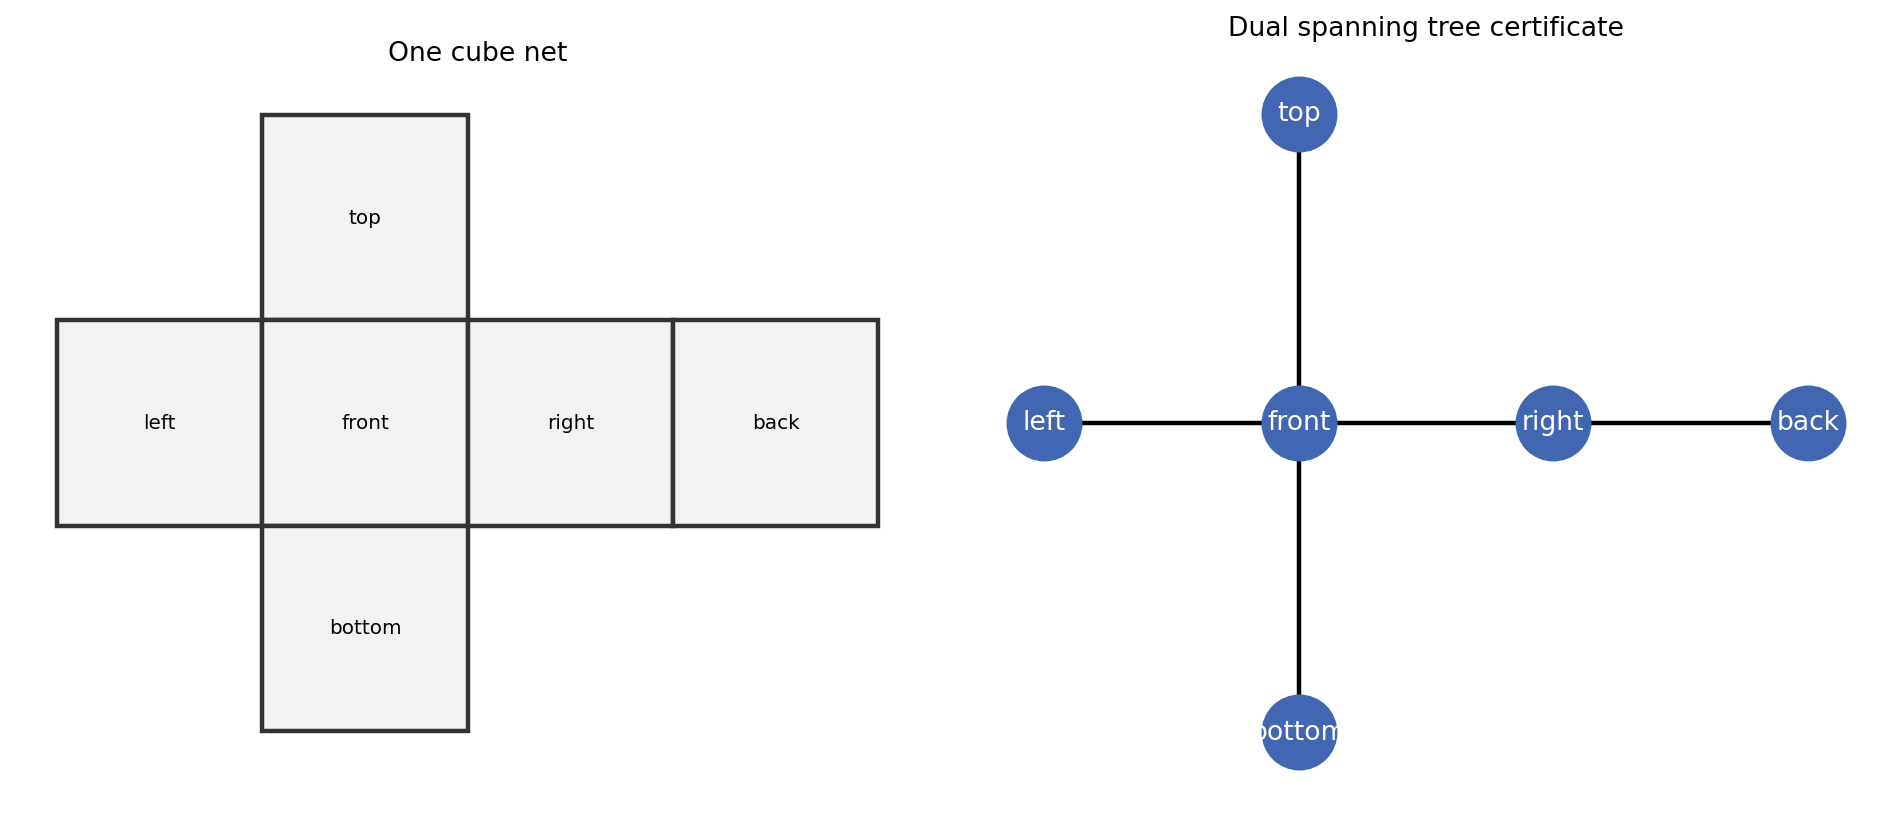

In [6]:
face_positions={'top':(1,2),'left':(0,1),'front':(1,1),'right':(2,1),'back':(3,1),'bottom':(1,0)}
dual_edges=[('front','top'),('front','bottom'),('front','left'),('front','right'),('right','back')]
Dual=nx.Graph(); Dual.add_nodes_from(face_positions); Dual.add_edges_from(dual_edges)
fig,axes=plt.subplots(1,2,figsize=(12,5.2))
for face,(x,y) in face_positions.items():
    axes[0].add_patch(Rectangle((x,y),1,1,facecolor='#f2f2f2',edgecolor='#333333',linewidth=2))
    axes[0].text(x+0.5,y+0.5,face,ha='center',va='center',fontsize=9)
axes[0].set_aspect('equal'); axes[0].set_xlim(-0.2,4.3); axes[0].set_ylim(-0.2,3.2); axes[0].set_title('One cube net'); axes[0].axis('off')
pos={'front':(0,0),'top':(0,1),'bottom':(0,-1),'left':(-1,0),'right':(1,0),'back':(2,0)}
nx.draw_networkx(Dual,pos,ax=axes[1],node_color='#4267b2',font_color='white',node_size=1100,width=2)
axes[1].set_title('Dual spanning tree certificate'); axes[1].axis('off')
fig.tight_layout()
net_plot=save_matplotlib(fig, FIGURES/'cube-net-dual-spanning-tree.png')
plt.close(fig)
net_check=save_json({'face_count':Dual.number_of_nodes(), 'dual_tree_edges':Dual.number_of_edges(), 'is_tree':nx.is_tree(Dual), 'tree_edges_equal_F_minus_1':Dual.number_of_edges()==Dual.number_of_nodes()-1}, CHECKS/'cube-net-spanning-tree-checks.json')
artifact_paths.extend([net_plot, net_check])
display_artifact(net_plot, width=900)


## 5. Shortest Paths, Cut Loci, Source Unfoldings, And Alexandrov Gluing

A shortest path on a polyhedral surface becomes a straight segment after cutting and unfolding the crossed faces. Cut loci and source unfoldings organize which cuts make those straight segments possible. Alexandrov gluing runs the logic in the other direction: start with polygons and edge identifications, require metric compatibility and vertex angle sums at most `2*pi`, and obtain a convex polyhedron when the total curvature is `4*pi`.


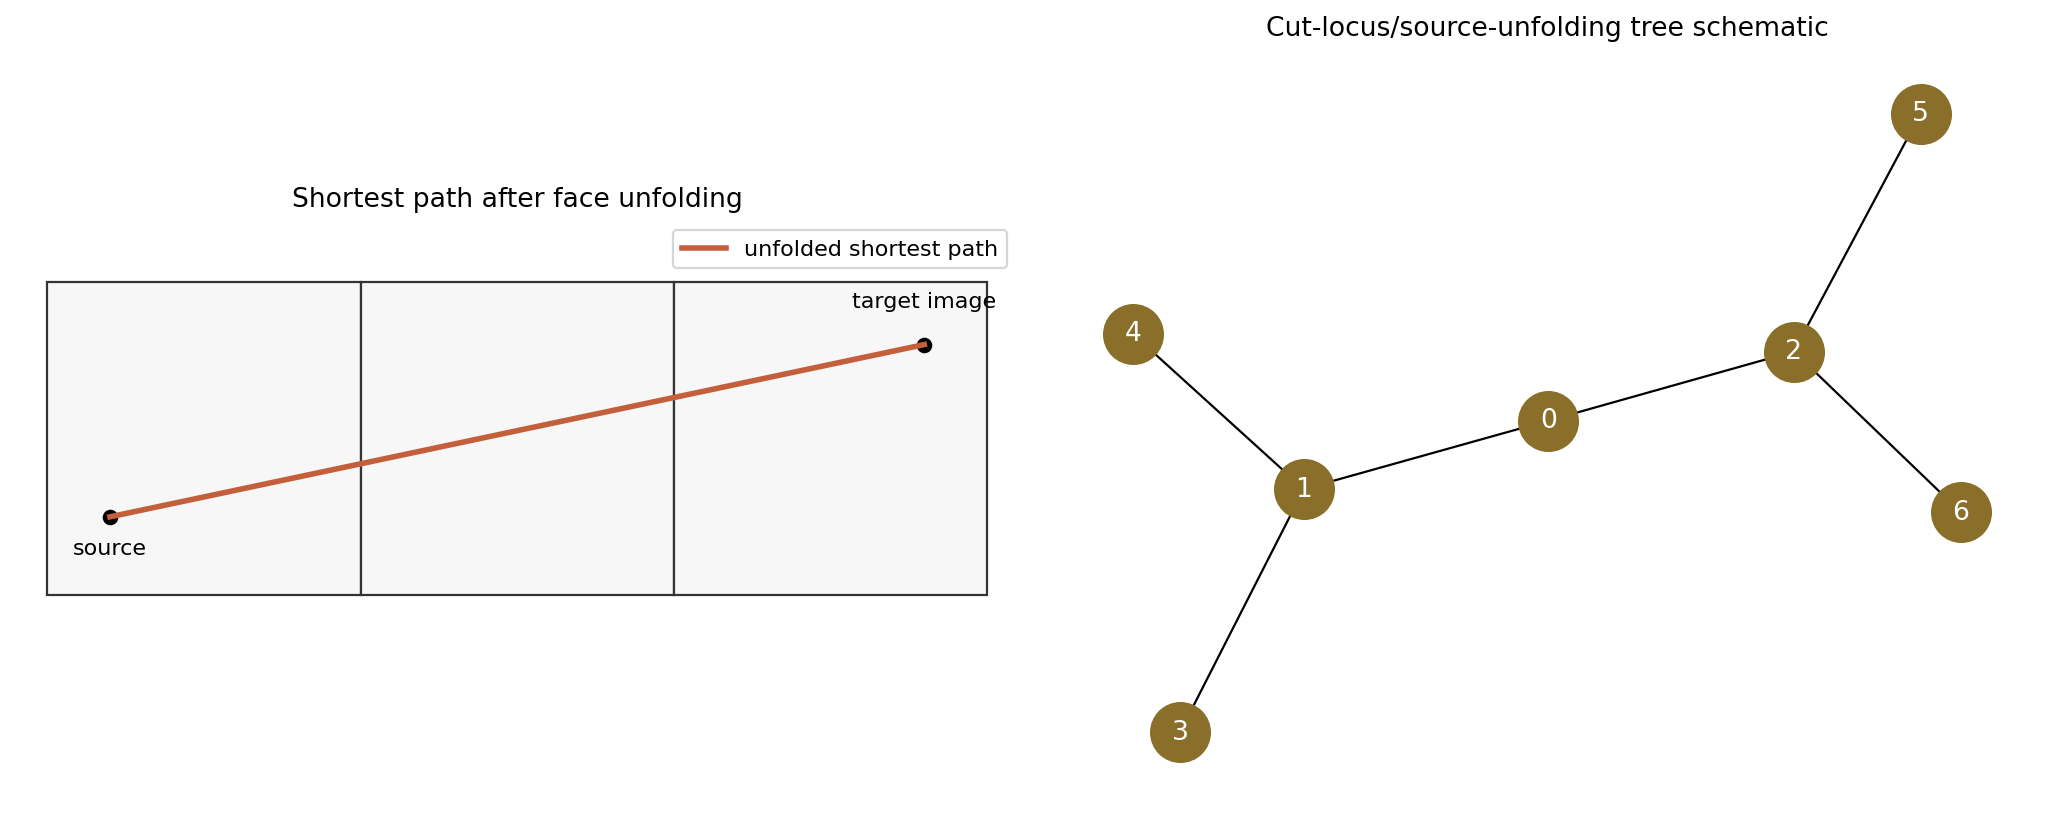

Alexandrov gluing ledger: `artifacts\chapter-07-polyhedra\tables\alexandrov-gluing-angle-ledger.csv`

In [7]:
fig,axes=plt.subplots(1,2,figsize=(13,5.2))
for k in range(3):
    axes[0].add_patch(Rectangle((k,0),1,1,facecolor='#f7f7f7',edgecolor='#333333'))
axes[0].plot([0.2,2.8],[0.25,0.8],color='#c45f3c',linewidth=2.5,label='unfolded shortest path')
axes[0].scatter([0.2,2.8],[0.25,0.8],color='black')
axes[0].text(0.2,0.13,'source',ha='center'); axes[0].text(2.8,0.92,'target image',ha='center')
axes[0].set_aspect('equal'); axes[0].set_xlim(-0.1,3.1); axes[0].set_ylim(-0.1,1.2); axes[0].set_title('Shortest path after face unfolding'); axes[0].legend(); axes[0].axis('off')
cut_tree=nx.balanced_tree(r=2,h=2)
pos=nx.spring_layout(cut_tree,seed=7)
nx.draw_networkx(cut_tree,pos,ax=axes[1],node_color='#8a6f2a',font_color='white',node_size=700)
axes[1].set_title('Cut-locus/source-unfolding tree schematic'); axes[1].axis('off')
fig.tight_layout()
shortest_plot=save_matplotlib(fig, FIGURES/'shortest-path-cut-locus-unfolding.png')
plt.close(fig)

gluing_rows=[
    {'glued_vertex':'A','incident_angles_pi_units':1.0,'angle_sum':math.pi,'curvature':math.pi},
    {'glued_vertex':'B','incident_angles_pi_units':1.5,'angle_sum':1.5*math.pi,'curvature':0.5*math.pi},
    {'glued_vertex':'C','incident_angles_pi_units':1.5,'angle_sum':1.5*math.pi,'curvature':0.5*math.pi},
    {'glued_vertex':'D','incident_angles_pi_units':0.0,'angle_sum':0.0,'curvature':2*math.pi},
]
# The D row models a collapsed cone point in a coarse ledger; all curvature is nonnegative and totals 4*pi.
gluing_table=save_csv(gluing_rows, TABLES/'alexandrov-gluing-angle-ledger.csv')
gluing_check=save_json({'all_angle_sums_at_most_2pi':all(r['angle_sum']<=2*math.pi+1e-12 for r in gluing_rows), 'total_curvature':sum(r['curvature'] for r in gluing_rows), 'total_curvature_is_4pi':abs(sum(r['curvature'] for r in gluing_rows)-4*math.pi)<1e-9, 'cut_locus_tree_edges':cut_tree.number_of_edges(), 'cut_locus_tree_is_tree':nx.is_tree(cut_tree)}, CHECKS/'shortest-path-alexandrov-checks.json')
artifact_paths.extend([shortest_plot, gluing_table, gluing_check])
display_artifact(shortest_plot, width=900)
display(Markdown(f'Alexandrov gluing ledger: `{gluing_table.relative_to(BOOK_ROOT)}`'))


## Applied Lab

Change a Platonic `(p,q)` pair and rerun the angle board. If the angle defect is zero or negative, the pair cannot be a convex regular polyhedron vertex. Then remove one edge from the cube dual tree: the net certificate becomes disconnected. Add one extra edge: the cut plan gains a dual cycle, which is not a spanning tree. These small failures are the fastest way to learn what the chapter's hypotheses are doing.


## Takeaways

- The five Platonic solids come from a local angle-defect inequality plus global Euler bookkeeping.
- Polyhedral Gauss-Bonnet is executable: sum vertex defects and get `4*pi` on a convex sphere-like surface.
- Rigidity, flexibility, and unfolding are different questions, even when they involve the same faces and edges.
- A cube net is not just a drawing; it has a dual spanning-tree certificate.
- Alexandrov gluing turns polygon edge identifications into a convex polyhedron only when the angle and curvature ledger passes.


In [8]:
# final_sanity
assert all(source_coverage.values())
assert all(r['euler_characteristic']==2 for r in platonic)
assert all(r['angle_defect']>0 for r in platonic)
assert all(abs(r['total_defect']-4*math.pi)<1e-9 for r in curvature_models)
assert nx.is_tree(Dual) and Dual.number_of_edges()==Dual.number_of_nodes()-1
assert nx.is_tree(cut_tree)
assert json.loads(gluing_check.read_text())['total_curvature_is_4pi']
assert_artifacts(artifact_paths, min_bytes=64)
final_sanity={'source_coverage_items':len(source_coverage), 'artifact_count':len(artifact_paths), 'platonic_cases':len(platonic), 'cube_net_tree_edges':Dual.number_of_edges(), 'status':'passed'}
final_sanity_path=save_json(final_sanity, CHECKS/'final-sanity.json')
assert_artifacts([final_sanity_path], min_bytes=64)
final_sanity


{'source_coverage_items': 10,
 'artifact_count': 17,
 'platonic_cases': 5,
 'cube_net_tree_edges': 5,
 'status': 'passed'}